# Analisis Pengaruh Sanitasi Air Bersih terhadap Kasus DBD

In [4]:
#@title Import Library dan Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Data
df = pd.read_csv('/content/hasil_etl.csv')

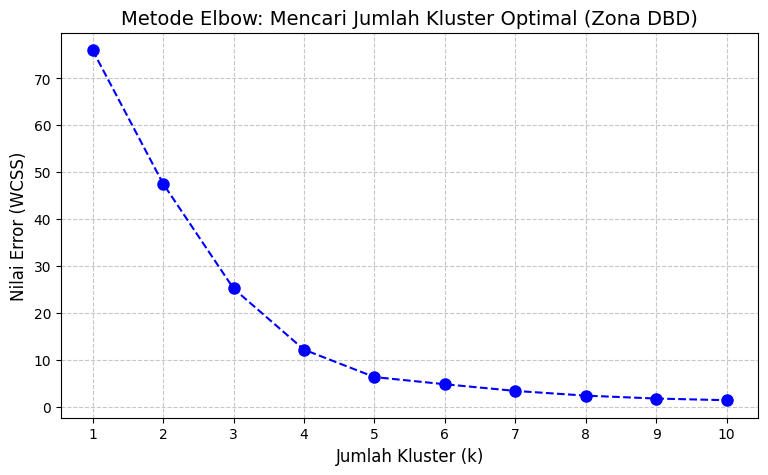

In [2]:
#@title Menentukan jumlah kluster dengan Metode Elbow

# Agregasi Data
df_agg = df.groupby('Provinsi').agg({
    'Akses_Air_Minum': 'mean',
    'Jumlah Kasus': 'mean'
}).reset_index()

X = df_agg[['Akses_Air_Minum', 'Jumlah Kasus']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inisiasi WCSS = Within-Cluster Sum of Square (Tingkat error)
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualisasi Grafik Siku
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b', markersize=8)


plt.title('Metode Elbow: Mencari Jumlah Kluster Optimal (Zona DBD)', fontsize=14)
plt.xlabel('Jumlah Kluster (k)', fontsize=12)
plt.ylabel('Nilai Error (WCSS)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

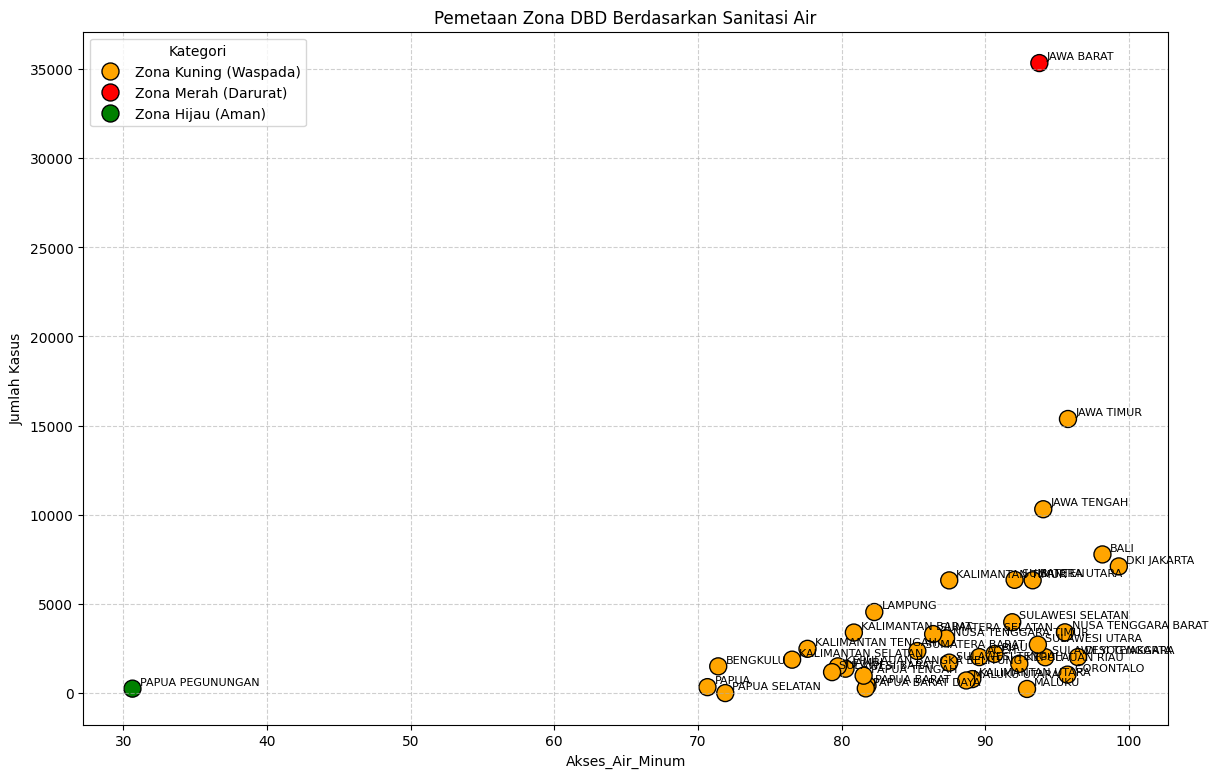

=== Hasil Kategori Zona DBD Tiap Provinsi ===
        Provinsi  Jumlah Kasus  Akses_Air_Minum               Kategori
0           ACEH       2017.75          89.5775  Zona Kuning (Waspada)
1           BALI       7775.75          98.1525  Zona Kuning (Waspada)
2         BANTEN       6325.00          93.2950  Zona Kuning (Waspada)
3       BENGKULU       1499.00          71.4100  Zona Kuning (Waspada)
4  DI YOGYAKARTA       2019.25          96.4475  Zona Kuning (Waspada)
5    DKI JAKARTA       7103.50          99.2925  Zona Kuning (Waspada)
6      GORONTALO       1034.75          95.7150  Zona Kuning (Waspada)
7          JAMBI       1367.25          80.2675  Zona Kuning (Waspada)
8     JAWA BARAT      35329.50          93.7600   Zona Merah (Darurat)
9    JAWA TENGAH      10309.75          94.0325  Zona Kuning (Waspada)


In [5]:
#@title Memetakan Kluster dengan hasil siku Elbow
# Merata-ratakan data 4 tahun (2021-2024) agar tiap provinsi hanya punya 1 titik stabil
df_agg = df.groupby('Provinsi').agg({
    'Akses_Air_Minum': 'mean',
    'Jumlah Kasus': 'mean'
}).reset_index()

# Siapkan fitur dan scaling (Buang kolom teks)
X = df_agg[['Akses_Air_Minum', 'Jumlah Kasus']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_agg['Cluster'] = kmeans.fit_predict(X_scaled)

# Mapping Otomatis (Zona DBD)
# Hitung rata-rata kasus DBD di tiap kluster
cluster_mean = df_agg.groupby('Cluster')['Jumlah Kasus'].mean()

# Urutkan dari rata-rata kasus terendah ke tertinggi
sorted_clusters = cluster_mean.sort_values().index

# Buat map Kasus rendah = Hijau, Tengah = Kuning, Tinggi = Merah
label_map = {
    sorted_clusters[0]: 'Zona Hijau (Aman)',
    sorted_clusters[1]: 'Zona Kuning (Waspada)',
    sorted_clusters[2]: 'Zona Merah (Darurat)'
}
df_agg['Kategori'] = df_agg['Cluster'].map(label_map)

# Visualisasi (Tanpa PCA, langsung sumbu asli)
plt.figure(figsize=(14, 9))
sns.scatterplot(data=df_agg, x='Akses_Air_Minum', y='Jumlah Kasus',
                hue='Kategori', palette={'Zona Hijau (Aman)': 'green',
                                         'Zona Kuning (Waspada)': 'orange',
                                         'Zona Merah (Darurat)': 'red'},
                s=150, edgecolor='black')

# Tambahkan teks nama provinsi di grafiknya
for i in range(len(df_agg)):
    plt.text(df_agg['Akses_Air_Minum'].iloc[i] + 0.5,
             df_agg['Jumlah Kasus'].iloc[i] + 200,
             df_agg['Provinsi'].iloc[i],
             fontsize=8)

plt.title('Pemetaan Zona DBD Berdasarkan Sanitasi Air')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Lihat Hasil Akhir
print("=== Hasil Kategori Zona DBD Tiap Provinsi ===")
print(df_agg[['Provinsi', 'Jumlah Kasus', 'Akses_Air_Minum', 'Kategori']].head(10))

In [6]:
#@title Export File
export = 'hasil_ml_clustering_zona_dbd.csv'
df_agg.to_csv(export, index=False)